Лабораторная №3: Дистанция должна быть от 0 до 64


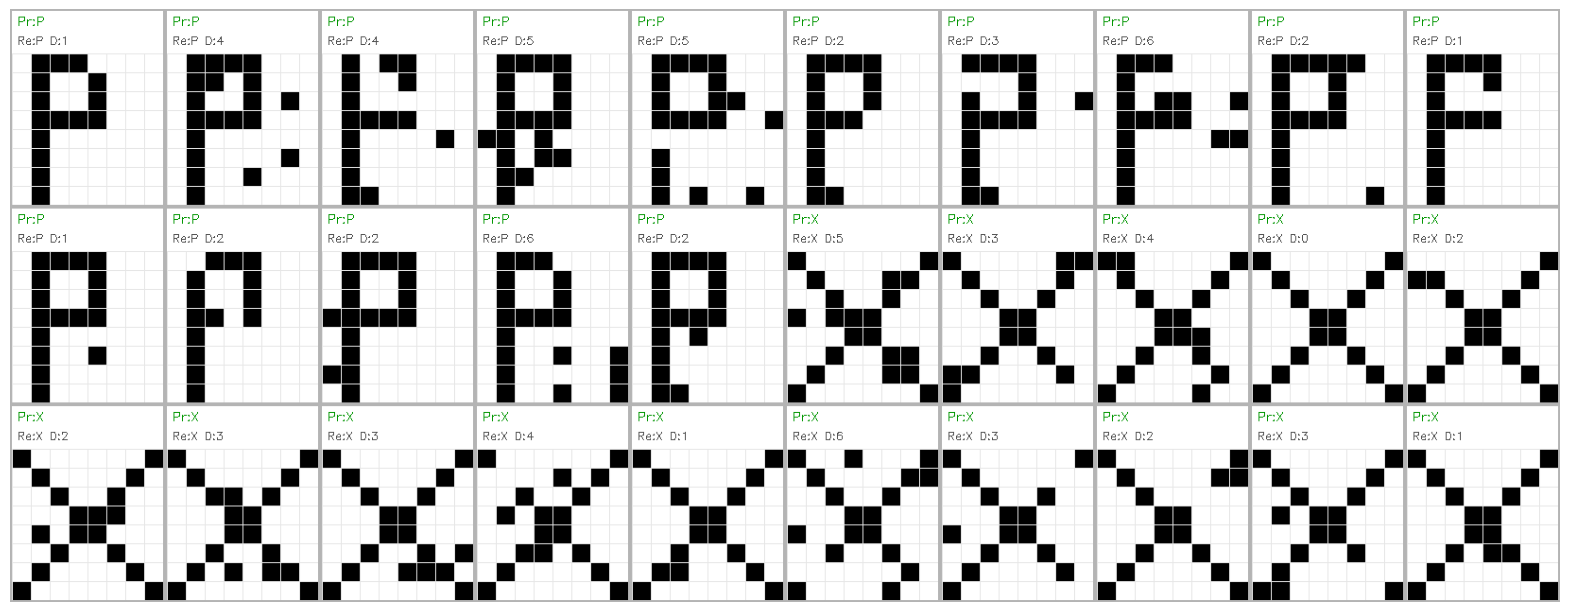

In [9]:
import numpy as np
import cv2
# from google.colab.patches import cv2_imshow
from matplotlib import pyplot as plt

def generate_samples():
    def add_noise(matrix, p=0.05):
        noise = np.random.choice([0, 1], size=(8, 8), p=[1-p, p])
        return np.logical_xor(matrix, noise).astype(int)

    base_P = np.zeros((8, 8), dtype=int)
    base_P[:, 1] = 1; base_P[0, 1:5] = 1; base_P[3, 1:5] = 1; base_P[1:3, 4] = 1

    base_X = np.eye(8, dtype=int); base_X = base_X + np.fliplr(base_X)
    base_X[base_X > 1] = 1

    train_P = [add_noise(base_P) for _ in range(15)]
    train_X = [add_noise(base_X) for _ in range(15)]

    return np.array(train_P), np.array(train_X), base_P, base_X

def levenshtein_distance(s1, s2):
    if len(s1) < len(s2):
        return levenshtein_distance(s2, s1)
    if len(s2) == 0:
        return len(s1)

    previous_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row
    return previous_row[-1]

class LevenshteinClassifier:
    def fit(self, templates):
        self.templates = {}
        for label, matrix in templates.items():
            flat_str = "".join(matrix.flatten().astype(int).astype(str))
            self.templates[label] = flat_str

    def predict(self, matrix):
        s_input = "".join(matrix.flatten().astype(int).astype(str))

        results = {}
        for label, s_template in self.templates.items():
            results[label] = levenshtein_distance(s_input, s_template)

        best_label = min(results, key=results.get)
        return best_label, results[best_label]

def draw_results(samples_P, samples_X, model):
    all_imgs = []
    pairs = [('P', s) for s in samples_P] + [('X', s) for s in samples_X]
    cell_size = 20

    for real, mat in pairs:
        pred, dist = model.predict(mat)

        img = np.full((8 * cell_size, 8 * cell_size, 3), 255, dtype=np.uint8)
        for r in range(8):
            for c in range(8):
                color = (0, 0, 0) if mat[r,c] == 1 else (255, 255, 255)
                cv2.rectangle(img, (c*cell_size, r*cell_size),
                             ((c+1)*cell_size, (r+1)*cell_size), color, -1)
                cv2.rectangle(img, (c*cell_size, r*cell_size),
                             ((c+1)*cell_size, (r+1)*cell_size), (230, 230, 230), 1)

        img = cv2.copyMakeBorder(img, 45, 0, 0, 0, cv2.BORDER_CONSTANT, value=(255, 255, 255))
        color = (0, 150, 0) if pred == real else (0, 0, 255)

        cv2.putText(img, f"Pr:{pred}", (5, 15), cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)
        cv2.putText(img, f"Re:{real} D:{dist}", (5, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (80, 80, 80), 1)

        img = cv2.copyMakeBorder(img, 2, 2, 2, 2, cv2.BORDER_CONSTANT, value=(180, 180, 180))
        all_imgs.append(img)

    rows = [np.hstack(all_imgs[i:i+10]) for i in range(0, 30, 10)]
    final_grid = np.vstack(rows)
    
    print("Лабораторная №3: Дистанция должна быть от 0 до 64")
    
    plt.figure(figsize=(20, 10))
    plt.imshow(cv2.cvtColor(final_grid, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

P_test, X_test, P_base, X_base = generate_samples()
model = LevenshteinClassifier()
model.fit({'P': P_base, 'X': X_base})
draw_results(P_test, X_test, model)

In [ ]:
import sys
!{sys.executable} -m pip install opencv-jupyter-ui